In [10]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:16pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [4]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 한글설정 및 미적속성 설정
sns.set(style='white',
        context='notebook',
        palette='Dark2',
        rc={'figure.figsize': (12,3),
            'font.family':'Malgun Gothic',
            'axes.unicode_minus':False})

# warning(경고) 안보이게
import warnings
warnings.filterwarnings(action='ignore')

# 모든 컬럼이 보이도록
pd.set_option('display.max_columns', None)

# 2. 데이터 파일 확인
- 아래 `%ls` 결과와 **2.1의 파일 이름이 다르면 2.1만 수정**한다

## 2.1 파일 경로

In [5]:
%ls "00_data/"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: A014-DCD6

 C:\ai\lecNote\09_project\00_data 디렉터리

2026-09-29  오후 05:41    <DIR>          .
2026-09-30  오후 12:17    <DIR>          ..
2026-09-29  오후 02:58        22,766,293 1_서울시 상권분석서비스(점포-상권)_2023년.csv
2026-09-29  오후 02:58        22,695,439 1_서울시 상권분석서비스(점포-상권)_2024년.csv
2026-09-29  오후 12:27        31,051,537 1_서울시 상권분석서비스(점포-상권)_2025년.csv
2026-09-28  오후 05:01           175,854 10_서울시 상권분석서비스(영역-상권).csv
2026-09-29  오후 12:27         3,124,101 2_서울시 상권분석서비스(상권변화지표-상권).csv
2026-09-29  오후 12:27        40,887,998 3_2023년 서울시 상권분석서비스(추정매출-상권).csv
2026-09-29  오후 12:27        40,356,222 3_2024년 서울시 상권분석서비스(추정매출-상권).csv
2026-09-29  오후 12:27        39,698,674 3_2025년 서울시 상권분석서비스(추정매출-상권).csv
2026-09-29  오후 12:27         8,543,807 4_ 서울시 상권분석서비스(길단위인구-상권).csv
2026-09-29  오후 12:27         6,687,358 5_ 서울시 상권분석서비스(상주인구-상권).csv
2026-09-29  오후 12:27         4,994,974 6_서울시 상권분석서비스(상주인구-상권배후지).csv
2026-09-29  오후 12:27             6,061 7_서울시 상권분석서비스(상주인구-서울시).csv
2

In [6]:
DATA_DIR = '00_data/'

file_store    = [DATA_DIR + '1_서울시 상권분석서비스(점포-상권)_2023년.csv',
                 DATA_DIR + '1_서울시 상권분석서비스(점포-상권)_2024년.csv',
                 DATA_DIR + '1_서울시 상권분석서비스(점포-상권)_2025년.csv']
file_change   = DATA_DIR + '2_서울시 상권분석서비스(상권변화지표-상권).csv'
file_sales    = [DATA_DIR + '3_2023년 서울시 상권분석서비스(추정매출-상권).csv',
                 DATA_DIR + '3_2024년 서울시 상권분석서비스(추정매출-상권).csv',
                 DATA_DIR + '3_2025년 서울시 상권분석서비스(추정매출-상권).csv']
file_flow     = DATA_DIR + '4_ 서울시 상권분석서비스(길단위인구-상권).csv'
file_res      = DATA_DIR + '5_ 서울시 상권분석서비스(상주인구-상권).csv'
file_res_bg   = DATA_DIR + '6_서울시 상권분석서비스(상주인구-상권배후지).csv'
file_res_seoul= DATA_DIR + '7_서울시 상권분석서비스(상주인구-서울시).csv'
file_res_gu   = DATA_DIR + '8_서울시 상권분석서비스(상주인구-자치구).csv'
file_res_dong = DATA_DIR + '9_서울시 상권분석서비스(상주인구-행정동).csv'
file_area     = DATA_DIR + '10_서울시 상권분석서비스(영역-상권).csv'

# 3. 데이터 읽어오기
- 모든 파일은 cp949 인코딩
## 3.1 추정매출 2023~2025 : 연도별 파일을 행으로 연결(concat)

In [11]:
store_list = []
for file in file_store:
    temp = pd.read_csv(file, encoding='cp949', low_memory=False)
    print(file.split('/')[-1], temp.shape)
    store_list.append(temp)

store = pd.concat(store_list, axis=0, ignore_index=True)   # axis=0 : 행으로 연결

1_서울시 상권분석서비스(점포-상권)_2023년.csv (307741, 14)
1_서울시 상권분석서비스(점포-상권)_2024년.csv (306889, 14)
1_서울시 상권분석서비스(점포-상권)_2025년.csv (304775, 14)


In [12]:
sales_list = []
for file in file_sales:
    temp = pd.read_csv(file, encoding='cp949', low_memory=False)
    print(file.split('/')[-1], temp.shape)
    sales_list.append(temp)

sales = pd.concat(sales_list, axis=0, ignore_index=True)   # axis=0 : 행으로 연결
print('연결 후 :', sales.shape)
sales['기준_년분기_코드'].value_counts().sort_index()

3_2023년 서울시 상권분석서비스(추정매출-상권).csv (88246, 55)
3_2024년 서울시 상권분석서비스(추정매출-상권).csv (87179, 55)
3_2025년 서울시 상권분석서비스(추정매출-상권).csv (85732, 55)
연결 후 : (261157, 55)


20231    22106
20232    22083
20233    22017
20234    22040
20241    21910
20242    21887
20243    21718
20244    21664
20251    21427
20252    21452
20253    21520
20254    21333
Name: 기준_년분기_코드, dtype: int64

## 3.2 나머지 파일

In [13]:
change    = pd.read_csv(file_change, encoding='cp949')
flow      = pd.read_csv(file_flow, encoding='cp949')
res       = pd.read_csv(file_res, encoding='cp949')
res_bg    = pd.read_csv(file_res_bg, encoding='cp949')
res_seoul = pd.read_csv(file_res_seoul, encoding='cp949')
res_gu    = pd.read_csv(file_res_gu, encoding='cp949')
res_dong  = pd.read_csv(file_res_dong, encoding='cp949')
area      = pd.read_csv(file_area, encoding='cp949')

for name, d in [('점포',store), ('상권변화지표',change), ('유동인구',flow), ('상주-상권',res), ('상주-배후지',res_bg),
                ('상주-서울시',res_seoul), ('상주-자치구',res_gu), ('상주-행정동',res_dong), ('영역-상권',area)]:
    print(f'{name:8s}', d.shape)

점포       (919405, 14)
상권변화지표   (36300, 11)
유동인구     (36281, 27)
상주-상권    (35908, 29)
상주-배후지   (23980, 29)
상주-서울시   (22, 27)
상주-자치구   (550, 27)
상주-행정동   (9350, 27)
영역-상권    (1650, 11)


# 4. 컬럼명 통일
## 4.1 점포 : 영문 → 한글

In [14]:
store = store.rename(columns={'stdr_yyqu_cd':'기준_년분기_코드',
                              'trdar_se_cd':'상권_구분_코드',
                              'trdar_se_cd_nm':'상권_구분_코드_명',
                              'trdar_cd':'상권_코드',
                              'trdar_cd_nm':'상권_코드_명',
                              'svc_induty_cd':'서비스_업종_코드',
                              'svc_induty_cd_nm':'서비스_업종_코드_명',
                              'stor_co':'점포_수',                        # 일반 점포(프랜차이즈 제외)
                              'similr_induty_stor_co':'유사_업종_점포_수',  # = 점포_수 + 프랜차이즈_점포_수
                              'opbiz_rt':'개업_율',
                              'opbiz_stor_co':'개업_점포_수',
                              'clsbiz_rt':'폐업_률',
                              'clsbiz_stor_co':'폐업_점포_수',
                              'frc_stor_co':'프랜차이즈_점포_수'})
# 전체 점포 수 (폐업률의 분모)
store['전체_점포_수'] = store['점포_수'] + store['프랜차이즈_점포_수']
store.head(3)

,기준_년분기_코드,상권_구분_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,전체_점포_수
0,20231,A,골목상권,3110001,이북5도청사,CS100001,한식음식점,10,11,9,1,0,0,1,11
1,20231,A,골목상권,3110001,이북5도청사,CS100003,일식음식점,1,1,0,0,0,0,0,1
2,20231,A,골목상권,3110001,이북5도청사,CS100008,분식전문점,3,3,0,0,0,0,0,3


## 4.2 추정매출 : 시간대 컬럼명 정리

In [15]:
time_cols = {}
for start, end in [('00','06'),('06','11'),('11','14'),('14','17'),('17','21'),('21','24')]:
    time_cols[f'시간대_{start}~{end}_매출_금액'] = f'시간대_{start}_{end}_매출_금액'
    time_cols[f'시간대_건수~{end}_매출_건수']    = f'시간대_{start}_{end}_매출_건수'
sales = sales.rename(columns=time_cols)
[col for col in sales.columns if '시간대' in col]

['시간대_00_06_매출_금액',
 '시간대_06_11_매출_금액',
 '시간대_11_14_매출_금액',
 '시간대_14_17_매출_금액',
 '시간대_17_21_매출_금액',
 '시간대_21_24_매출_금액',
 '시간대_00_06_매출_건수',
 '시간대_06_11_매출_건수',
 '시간대_11_14_매출_건수',
 '시간대_14_17_매출_건수',
 '시간대_17_21_매출_건수',
 '시간대_21_24_매출_건수']

# 5. 상권 매핑표 (상권 → 자치구·행정동·위경도)
- 좌표 EPSG:5181 → 위경도 EPSG:4326 변환

In [16]:
from pyproj import Transformer
tf = Transformer.from_crs('EPSG:5181', 'EPSG:4326', always_xy=True)
area['경도'], area['위도'] = tf.transform(area['엑스좌표_값'].values, area['와이좌표_값'].values)

mapping = area[['상권_코드','자치구_코드','자치구_코드_명','행정동_코드','행정동_코드_명','위도','경도','영역_면적']]
mapping.head(3)

,상권_코드,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,위도,경도,영역_면적
0,3110055,11140,중구,11140670,황학동,37.569879,127.018587,27575
1,3110008,11110,종로구,11110515,청운효자동,37.580309,126.967090,149264
2,3110009,11110,종로구,11110550,부암동,37.595076,126.965928,178306


# 6. 병합 → 하나의 DataFrame (`dataset`)
- 기준 : 추정매출 2023~2025 (`how='left'` : 기준 행은 모두 남기고 옆에 붙임)
- 붙이는 쪽의 이름 컬럼(상권_코드_명 등)은 빼서 `_x`, `_y` 중복을 막는다

In [17]:
key3 = ['기준_년분기_코드','상권_코드','서비스_업종_코드']   # 상권×업종×분기
key2 = ['기준_년분기_코드','상권_코드']                     # 상권×분기
drop_names = ['상권_구분_코드','상권_구분_코드_명','상권_코드_명','서비스_업종_코드_명']

dataset = sales.copy()
print('기준(추정매출) :', dataset.shape)

기준(추정매출) : (261157, 55)


## 6.1 + 점포 (2025년만 있음 → 2023·2024년 행은 NaN)

In [18]:
dataset = dataset.merge(store.drop(columns=drop_names), on=key3, how='left')
dataset['점포_데이터_있음'] = dataset['전체_점포_수'].notna().astype(int)
print(dataset.shape)
dataset.groupby('기준_년분기_코드')['점포_데이터_있음'].mean()

(261157, 64)


기준_년분기_코드
20231    1.0
20232    1.0
20233    1.0
20234    1.0
20241    1.0
20242    1.0
20243    1.0
20244    1.0
20251    1.0
20252    1.0
20253    1.0
20254    1.0
Name: 점포_데이터_있음, dtype: float64

## 6.2 + 유동인구, 상주인구, 상권변화지표 (상권 × 분기)

In [19]:
dataset = dataset.merge(flow.drop(columns=['상권_구분_코드','상권_구분_코드_명','상권_코드_명']), on=key2, how='left')
dataset = dataset.merge(res.drop(columns=['상권_구분_코드','상권_구분_코드_명','상권_코드_명']), on=key2, how='left')
dataset = dataset.merge(change.drop(columns=['상권_구분_코드','상권_구분_코드_명','상권_코드_명']), on=key2, how='left')
dataset.shape

(261157, 116)

## 6.3 + 배후지 상주인구 (골목상권만 제공, `상권배후지_코드` = `상권_코드`)

In [20]:
res_bg2 = res_bg.rename(columns={'상권배후지_코드':'상권_코드',
                                 '총_상주인구_수':'배후지_총_상주인구_수',
                                 '총_가구_수':'배후지_총_가구_수'})
res_bg2 = res_bg2[['기준_년분기_코드','상권_코드','배후지_총_상주인구_수','배후지_총_가구_수']]
dataset = dataset.merge(res_bg2, on=key2, how='left')
dataset.shape

(261157, 118)

## 6.4 + 상권 매핑 (자치구·행정동·위경도)

In [21]:
dataset = dataset.merge(mapping, on='상권_코드', how='left')
dataset.shape

(261157, 125)

## 6.5 + 자치구·행정동·서울시 상주인구

In [22]:
gu = res_gu[['기준_년분기_코드','자치구_코드','총_상주인구_수','총_가구_수']]
gu = gu.rename(columns={'총_상주인구_수':'자치구_총_상주인구_수', '총_가구_수':'자치구_총_가구_수'})

dong = res_dong[['기준_년분기_코드','행정동_코드','총_상주인구_수','총_가구_수']]
dong = dong.rename(columns={'총_상주인구_수':'행정동_총_상주인구_수', '총_가구_수':'행정동_총_가구_수'})

seoul = res_seoul[['기준_년분기_코드','총_상주인구_수']]
seoul = seoul.rename(columns={'총_상주인구_수':'서울_총_상주인구_수'})

dataset = dataset.merge(gu, on=['기준_년분기_코드','자치구_코드'], how='left')
dataset = dataset.merge(dong, on=['기준_년분기_코드','행정동_코드'], how='left')
dataset = dataset.merge(seoul, on='기준_년분기_코드', how='left')
dataset.shape

(261157, 130)

## 6.6 사용하지 않을 컬럼 제거
- `아파트_가구_수` : 모든 행이 0 / `비_아파트_가구_수` : 총_가구_수와 같음 / `상권_구분_코드` : 한글명과 중복

In [23]:
dataset = dataset.drop(columns=['아파트_가구_수','비_아파트_가구_수','상권_구분_코드'])
dataset = dataset.sort_values(['상권_코드','서비스_업종_코드','기준_년분기_코드']).reset_index(drop=True)
dataset.shape

(261157, 127)

In [24]:
print('추정매출 행 수 :', len(sales), '/ dataset 행 수 :', len(dataset))
print('키 중복 :', dataset.duplicated(key3).sum())
print('_x, _y 컬럼 :', [col for col in dataset.columns if col.endswith(('_x','_y'))])
print('상권 수 :', dataset['상권_코드'].nunique(), '/ 업종 수 :', dataset['서비스_업종_코드'].nunique(),
      '/ 자치구 수 :', dataset['자치구_코드_명'].nunique())

추정매출 행 수 : 261157 / dataset 행 수 : 261157
키 중복 : 0
_x, _y 컬럼 : []
상권 수 : 1587 / 업종 수 : 63 / 자치구 수 : 25


In [25]:
# 결합률 : 붙인 데이터가 몇 % 행에 채워졌는지
check_cols = {'점포(2025만)':'전체_점포_수',
              '유동인구':'총_유동인구_수',
              '상주인구':'총_상주인구_수',
              '상권변화지표':'상권_변화_지표',
              '배후지 상주':'배후지_총_상주인구_수',
              '자치구 매핑':'자치구_코드_명',
              '자치구 상주':'자치구_총_상주인구_수',
              '행정동 상주':'행정동_총_상주인구_수'}
join_rate = pd.Series({name: dataset[col].notna().mean()*100 for name, col in check_cols.items()})
join_rate.round(1)

점포(2025만)    100.0
유동인구         100.0
상주인구          99.6
상권변화지표       100.0
배후지 상주        50.4
자치구 매핑       100.0
자치구 상주       100.0
행정동 상주       100.0
dtype: float64

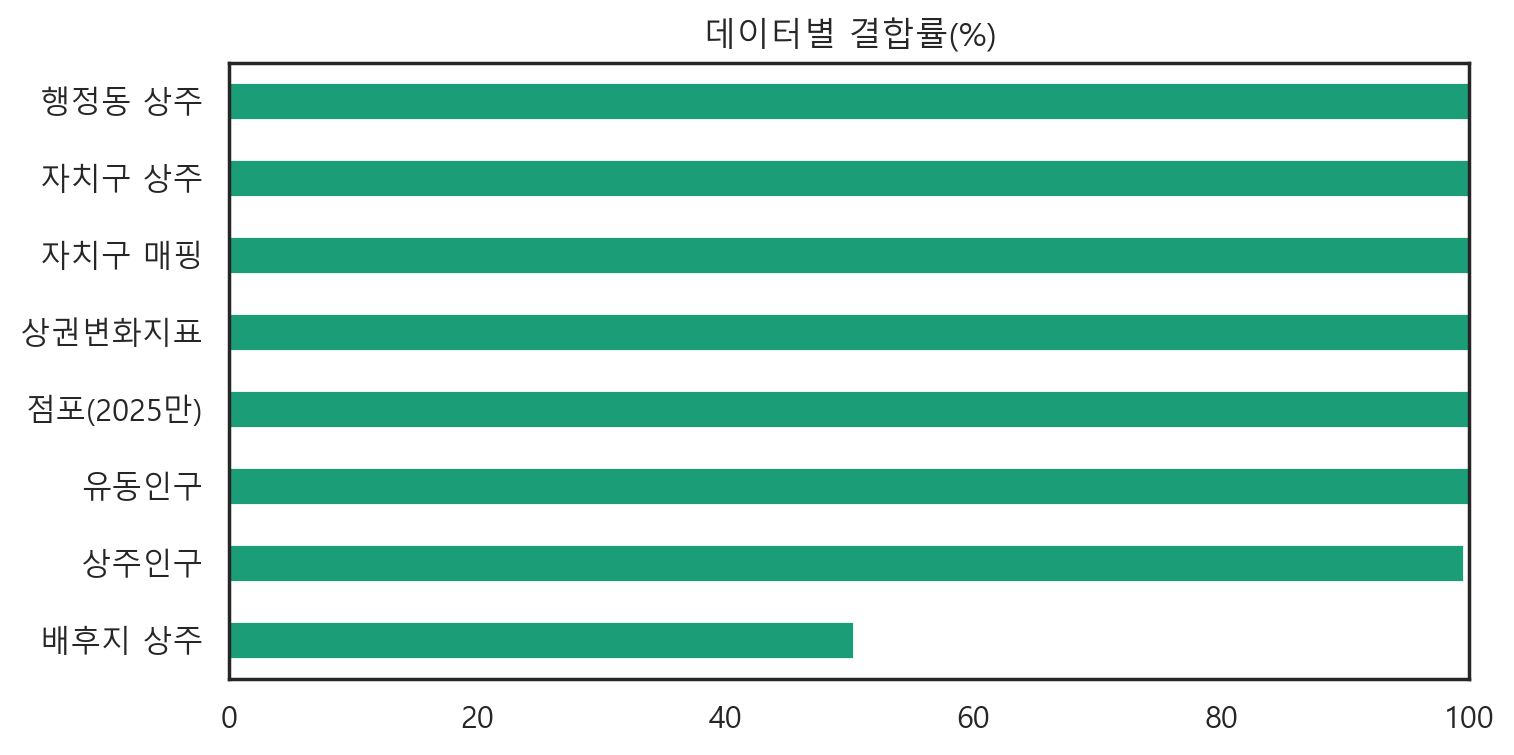

In [26]:
join_rate.sort_values().plot.barh(figsize=(8,4))
plt.title('데이터별 결합률(%)')
plt.xlim(0,100)
plt.show()

In [27]:
# 분기별 행 수와 점포 데이터 유무
pd.crosstab(dataset['기준_년분기_코드'], dataset['점포_데이터_있음'])

점포_데이터_있음,1
기준_년분기_코드,
20231,22106
20232,22083
20233,22017
20234,22040
20241,21910
20242,21887
20243,21718
20244,21664
20251,21427


- 점포 약 1/3 : **점포 파일이 2025년만** 있어서 2023·2024년 행은 비어 있음
  → 점포-상권 2023·2024년 파일을 추가하면 폐업위기(M1) 학습 기간이 12개 분기로 늘어남
- 배후지 상주 : 골목상권만 제공 → 정상

- `dataset_상권_업종_분기.csv` : 통합 데이터셋
- `label_source.csv` : 점포 파일 전체(100개 업종) — 다음 분기 폐업률(M1 정답)을 만들 때 사용

In [29]:
os.makedirs(DATA_DIR + 'processed', exist_ok=True)
store.to_csv(DATA_DIR + 'processed/label_source.csv', index=False, encoding='utf-8-sig')
dataset.to_csv(DATA_DIR + 'processed/dataset_상권_업종_분기.csv', index=False, encoding='utf-8-sig')
print('저장 완료 :', dataset.shape)

저장 완료 : (261157, 127)


,기준_년분기_코드,상권_구분_코드_명,상권_코드,상권_코드_명,서비스_업종_코드,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,월요일_매출_금액,화요일_매출_금액,수요일_매출_금액,목요일_매출_금액,금요일_매출_금액,토요일_매출_금액,일요일_매출_금액,시간대_00_06_매출_금액,시간대_06_11_매출_금액,시간대_11_14_매출_금액,시간대_14_17_매출_금액,시간대_17_21_매출_금액,시간대_21_24_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액,주중_매출_건수,주말_매출_건수,월요일_매출_건수,화요일_매출_건수,수요일_매출_건수,목요일_매출_건수,금요일_매출_건수,토요일_매출_건수,일요일_매출_건수,시간대_00_06_매출_건수,시간대_06_11_매출_건수,시간대_11_14_매출_건수,시간대_14_17_매출_건수,시간대_17_21_매출_건수,시간대_21_24_매출_건수,남성_매출_건수,여성_매출_건수,연령대_10_매출_건수,연령대_20_매출_건수,연령대_30_매출_건수,연령대_40_매출_건수,연령대_50_매출_건수,연령대_60_이상_매출_건수,점포_수,유사_업종_점포_수,개업_율,개업_점포_수,폐업_률,폐업_점포_수,프랜차이즈_점포_수,전체_점포_수,점포_데이터_있음,총_유동인구_수,남성_유동인구_수,여성_유동인구_수,연령대_10_유동인구_수,연령대_20_유동인구_수,연령대_30_유동인구_수,연령대_40_유동인구_수,연령대_50_유동인구_수,연령대_60_이상_유동인구_수,시간대_00_06_유동인구_수,시간대_06_11_유동인구_수,시간대_11_14_유동인구_수,시간대_14_17_유동인구_수,시간대_17_21_유동인구_수,시간대_21_24_유동인구_수,월요일_유동인구_수,화요일_유동인구_수,수요일_유동인구_수,목요일_유동인구_수,금요일_유동인구_수,토요일_유동인구_수,일요일_유동인구_수,총_상주인구_수,남성_상주인구_수,여성_상주인구_수,연령대_10_상주인구_수,연령대_20_상주인구_수,연령대_30_상주인구_수,연령대_40_상주인구_수,연령대_50_상주인구_수,연령대_60_이상_상주인구_수,남성연령대_10_상주인구_수,남성연령대_20_상주인구_수,남성연령대_30_상주인구_수,남성연령대_40_상주인구_수,남성연령대_50_상주인구_수,남성연령대_60_이상_상주인구_수,여성연령대_10_상주인구_수,여성연령대_20_상주인구_수,여성연령대_30_상주인구_수,여성연령대_40_상주인구_수,여성연령대_50_상주인구_수,여성연령대_60_이상_상주인구_수,총_가구_수,상권_변화_지표,상권_변화_지표_명,운영_영업_개월_평균,폐업_영업_개월_평균,서울_운영_영업_개월_평균,서울_폐업_영업_개월_평균,배후지_총_상주인구_수,배후지_총_가구_수,자치구_코드,자치구_코드_명,행정동_코드,행정동_코드_명,위도,경도,영역_면적,자치구_총_상주인구_수,자치구_총_가구_수,행정동_총_상주인구_수,행정동_총_가구_수,서울_총_상주인구_수
0,20231,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,8510268369,185546,5292714225,3217554144,783890411,985835188,1100662807,1057643752,1364682067,1814720003,1402834141,816154187,255574788,1517596240,985728559,2930484049,2004730546,3979353887,3538190913,22604517,2203548383,2787902263,1143132700,804277234,556079704,116366,69180,19056,21241,24413,23118,28538,37939,31241,18804,6814,54274,26305,52581,26768,90904,81691,699,50925,59104,26948,20469,14442,117,126,4,5,4,5,9,126,1,2014294.0,1003011.0,1011283.0,133431.0,459329.0,494293.0,356837.0,262925.0,307480.0,379309.0,363980.0,290131.0,318829.0,415315.0,246730.0,269770.0,274678.0,280164.0,281485.0,296158.0,319069.0,292968.0,5337.0,2516.0,2821.0,315.0,322.0,963.0,882.0,866.0,1989.0,156.0,152.0,510.0,451.0,417.0,830.0,159.0,170.0,453.0,431.0,449.0,1159.0,3300.0,LH,상권확장,93,56,100,51,NaN,NaN,11170,용산구,11170650,이태원1동,37.534300,126.994320,372565,219681,112556,7126,3935,9410744
1,20232,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,10471475721,234729,6250909893,4220565828,1113285149,1231610152,1068034811,1184271065,1653708716,2301369712,1919196116,1573134157,380194591,1615613447,1121981113,3212270867,2568281546,5271546885,4017671459,33632029,2674079852,3496442917,1540229198,934121409,610712936,136495,98234,26997,24917,23576,25861,35144,51695,46539,39764,9674,55102,28824,61341,40024,119032,101670,1205,67392,77593,32874,25277,16359,119,128,2,3,1,1,9,128,1,2169881.0,1090454.0,1079427.0,131269.0,521113.0,530068.0,376442.0,278427.0,332563.0,416788.0,380130.0,309887.0,335768.0,452888.0,274421.0,284666.0,286094.0,290845.0,297342.0,319737.0,358768.0,332428.0,5337.0,2516.0,2821.0,315.0,322.0,963.0,882.0,866.0,1989.0,156.0,152.0,510.0,451.0,417.0,830.0,159.0,170.0,453.0,431.0,449.0,1159.0,3300.0,LH,상권확장,94,56,100,51,NaN,NaN,11170,용산구,11170650,이태원1동,37.534300,126.994320,372565,219681,112556,7126,3935,9410744
2,20233,관광특구,3001491,이태원 관광특구,CS100001,한식음식점,11852127714,272930,6424789214,5427338500,1078271064,1115386932,1323497250,1274921126,1632712842,3095390096,2331948404,2067470121,486898843,1774355599,1240932607,3728663946,2553806598,5918709267,4707884612,47966816,3568263609,3765880593,1551952269,1081269508,611261089,144775,128155,27059,25453,27678,28399,36186,70333,57822,58521,12531,56442,31355,69358,44723,140793,118335,1656,89780,88252,35008,27981,16442,117,127,3,4,4,5,10,127,1,2131046.0,1074138.0,1056906.0,130989.0,539009.0,521664.0,361889.0,262902.0,314593.0,433157.0,365611.0,294911.0,319401.0,437889.0,280078.0,2794

In [32]:
dataset['배후지_있음'] = dataset['배후지_총_상주인구_수'].notna().astype(int)
dataset[['배후지_총_상주인구_수','배후지_총_가구_수']] = dataset[['배후지_총_상주인구_수','배후지_총_가구_수']].fillna(0)

In [42]:
os.makedirs(DATA_DIR + 'processed', exist_ok=True)
store.to_csv(DATA_DIR + 'processed/label_source.csv', index=False, encoding='utf-8-sig')
dataset.to_csv(DATA_DIR + 'processed/dataset_상권_업종_분기.csv', index=False, encoding='utf-8-sig')
print('저장 완료 :', dataset.shape)

저장 완료 : (261157, 128)


In [43]:
file_rate = DATA_DIR + '한국_기준금리_과거데이터.xlsx' 

In [44]:
rate = pd.read_excel(file_rate, sheet_name='월별시계열', header=6)
rate = rate[['기준월', '기준금리(연%)']]
rate['기준월'] = pd.to_datetime(rate['기준월'])
print(rate.shape)
rate.tail()

(328, 2)


,기준월,기준금리(연%)
323,2026-04-01,2.50
324,2026-05-01,2.50
325,2026-06-01,2.50
326,2026-07-01,2.75
327,2026-08-01,3.00


In [45]:
rate['기준_년분기_코드'] = rate['기준월'].dt.year * 10 + rate['기준월'].dt.quarter

rate_q = rate.groupby('기준_년분기_코드')['기준금리(연%)'].mean().reset_index()
rate_q = rate_q.rename(columns={'기준금리(연%)':'기준금리'})
rate_q['기준금리_변화'] = rate_q['기준금리'].diff()        # 전분기 대비 (%p)
rate_q = rate_q.round(3)

# 데이터셋 기간(2023~2025)만 확인
rate_q[(rate_q['기준_년분기_코드'] >= 20231) & (rate_q['기준_년분기_코드'] <= 20254)]

,기준_년분기_코드,기준금리,기준금리_변화
95,20231,3.500,0.333
96,20232,3.500,0.000
97,20233,3.500,0.000
98,20234,3.500,0.000
99,20241,3.500,0.000
100,20242,3.500,0.000
101,20243,3.500,0.000
102,20244,3.083,-0.417
103,20251,2.833,-0.250
104,20252,2.583,-0.250


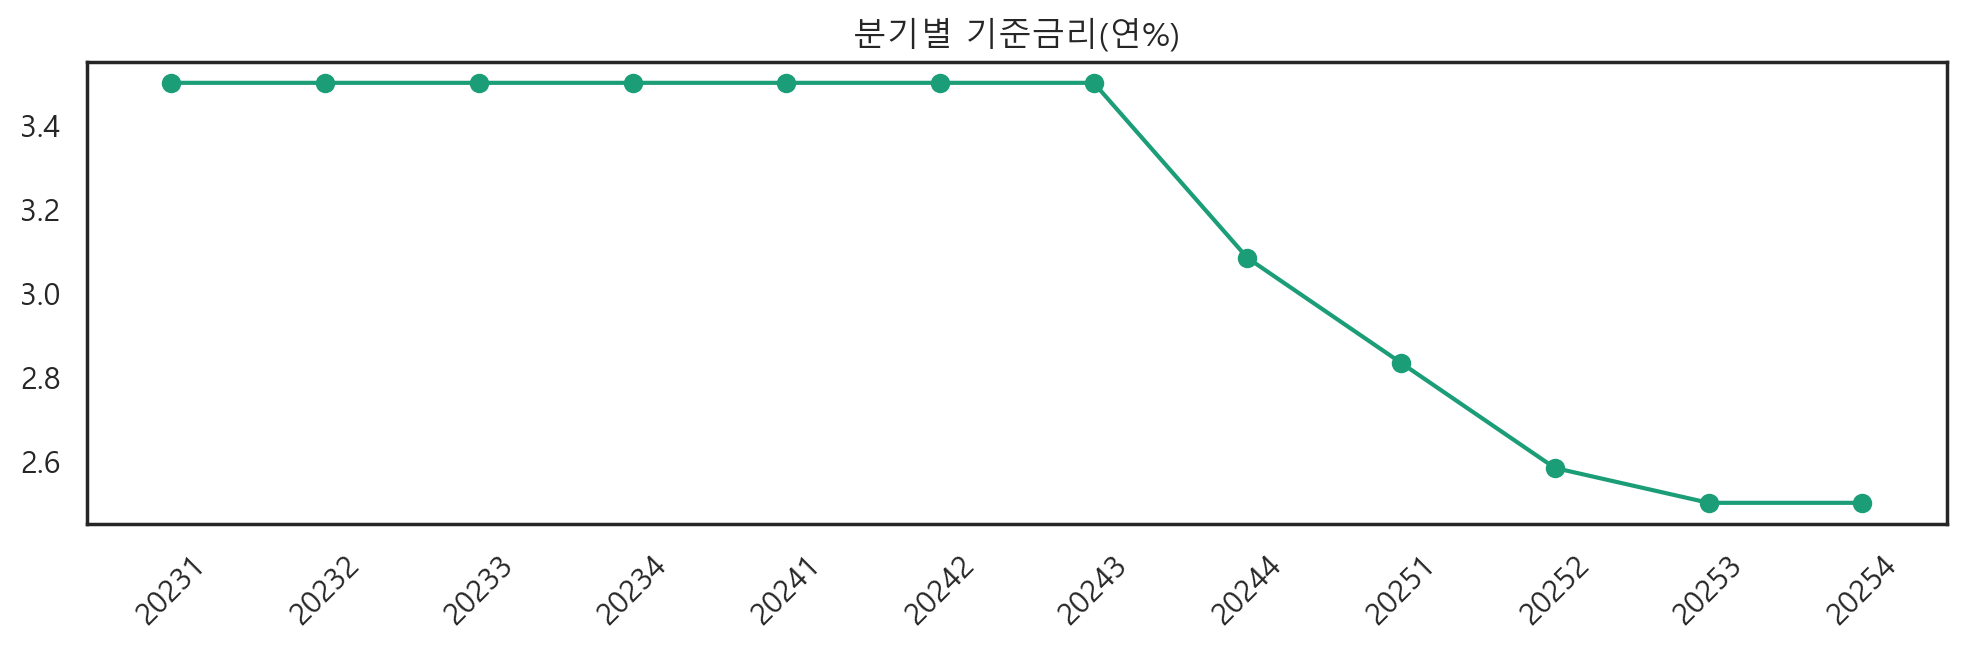

In [46]:
# 분기별 기준금리 추이
temp = rate_q[(rate_q['기준_년분기_코드'] >= 20231) & (rate_q['기준_년분기_코드'] <= 20254)]
plt.plot(temp['기준_년분기_코드'].astype(str), temp['기준금리'], marker='o')
plt.title('분기별 기준금리(연%)')
plt.xticks(rotation=45)
plt.show()

In [47]:
before = dataset.shape
final = dataset.merge(rate_q, on='기준_년분기_코드', how='left')
print('병합 전 :', before, '→ 병합 후 :', final.shape)

병합 전 : (261157, 128) → 병합 후 : (261157, 130)


In [48]:
dataset.shape

(261157, 128)

In [51]:
final.columns

Index(['기준_년분기_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '서비스_업종_코드',
       '서비스_업종_코드_명', '당월_매출_금액', '당월_매출_건수', '주중_매출_금액', '주말_매출_금액',
       ...
       '경도', '영역_면적', '자치구_총_상주인구_수', '자치구_총_가구_수', '행정동_총_상주인구_수',
       '행정동_총_가구_수', '서울_총_상주인구_수', '배후지_있음', '기준금리', '기준금리_변화'],
      dtype='object', length=130)

In [52]:
final.to_csv(DATA_DIR + 'processed/dataset_상권_업종_분기.csv', index=False, encoding='utf-8-sig')
print('저장 완료 :', dataset.shape)

저장 완료 : (261157, 128)


In [8]:
final = pd.read_csv('00_data/processed/dataset_상권_업종_분기.csv')
final.shape

(261157, 130)

In [11]:
final['기준_년분기_코드'].value_counts().sort_index()

20231    22106
20232    22083
20233    22017
20234    22040
20241    21910
20242    21887
20243    21718
20244    21664
20251    21427
20252    21452
20253    21520
20254    21333
Name: 기준_년분기_코드, dtype: int64

In [12]:
df = final.sort_values(['상권_코드','서비스_업종_코드','기준_년분기_코드']).reset_index(drop=True)
df[['상권_코드','서비스_업종_코드','기준_년분기_코드','폐업_점포_수','전체_점포_수']].head(5)

,상권_코드,서비스_업종_코드,기준_년분기_코드,폐업_점포_수,전체_점포_수
0,3001491,CS100001,20231,5,126
1,3001491,CS100001,20232,1,128
2,3001491,CS100001,20233,5,127
3,3001491,CS100001,20234,1,128
4,3001491,CS100001,20241,4,134


# 7. 종속변수 폐업위기값 정의 및생성

## 7.1다음 분기 값 당겨오기 : `shift(-1)`
- 같은 상권·업종 그룹 안에서 한 칸 위로 당김 → 다음 분기 값이 이번 분기 행에 붙음

In [13]:
group = df.groupby(['상권_코드','서비스_업종_코드'])
df['다음분기_코드']         = group['기준_년분기_코드'].shift(-1)
df['다음분기_폐업_점포_수'] = group['폐업_점포_수'].shift(-1)
df['다음분기_전체_점포_수'] = group['전체_점포_수'].shift(-1)
df[['상권_코드','서비스_업종_코드','기준_년분기_코드','폐업_점포_수','다음분기_코드','다음분기_폐업_점포_수']].head(5)

,상권_코드,서비스_업종_코드,기준_년분기_코드,폐업_점포_수,다음분기_코드,다음분기_폐업_점포_수
0,3001491,CS100001,20231,5,20232.0,1.0
1,3001491,CS100001,20232,1,20233.0,5.0
2,3001491,CS100001,20233,5,20234.0,1.0
3,3001491,CS100001,20234,1,20241.0,4.0
4,3001491,CS100001,20241,4,20242.0,8.0


## 7.2 바로 다음 분기인지 확인
- 중간 분기가 빠진 경우(예 : 20242 다음 행이 20244) → 다음 분기 값이 아니므로 빈칸 처리
- 4분기 다음은 **다음 해 1분기** (20234 → 20241)

In [14]:
year = df['기준_년분기_코드'] // 10
quarter = df['기준_년분기_코드'] % 10
df['정상_다음분기'] = np.where(quarter == 4, (year + 1) * 10 + 1, df['기준_년분기_코드'] + 1)

not_next = df['다음분기_코드'] != df['정상_다음분기']
print('다음 분기가 바로 이어지지 않는 행 :', not_next.sum())
df.loc[not_next, ['다음분기_폐업_점포_수','다음분기_전체_점포_수']] = np.nan
df = df.drop(columns=['다음분기_코드','정상_다음분기'])

다음 분기가 바로 이어지지 않는 행 : 27740


## 7.3. 다음 분기 폐업률

In [18]:
df['다음분기_폐업률'] = df['다음분기_폐업_점포_수'] / df['다음분기_전체_점포_수'] * 100
df['다음분기_폐업률'] = df['다음분기_폐업률'].clip(upper=100)       # 100% 초과값 상한
df['다음분기_폐업률'].describe()

count    233417.000000
mean          2.759026
std           7.161354
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         100.000000
Name: 다음분기_폐업률, dtype: float64

## 7.4 같은 분기·같은 업종 서울 평균 폐업률
- 서울 전체 해당 업종의 **폐업 점포 합계 ÷ 전체 점포 합계** (점포 수를 반영한 평균)
- `transform('sum')` : 그룹 합계를 원래 행 수 그대로 돌려줌

In [20]:
total = df.groupby(['기준_년분기_코드','서비스_업종_코드'])[['다음분기_폐업_점포_수','다음분기_전체_점포_수']].transform('sum')
df['업종평균_폐업률'] = total['다음분기_폐업_점포_수'] / total['다음분기_전체_점포_수'] * 100

# 업종별 평균 폐업률 예시 (2025년 2분기 기준)
df[df['기준_년분기_코드']==20252].groupby('서비스_업종_코드_명')['업종평균_폐업률'].first().sort_values(ascending=False).head(10).round(2)

서비스_업종_코드_명
PC방        4.84
중식음식점      4.57
호프-간이주점    4.54
커피-음료      4.38
분식전문점      4.04
양식음식점      3.95
패스트푸드점     3.90
애완동물       3.88
일식음식점      3.72
한식음식점      3.67
Name: 업종평균_폐업률, dtype: float64

## 7.5 종속변수 y : 폐업위기 (0/1)
- 다음 분기 폐업률 > 업종 평균 → 1
- 다음 분기 값이 없는 행(2025년 4분기, 분기 누락) → NaN (학습에서 제외, 2025년 4분기는 예측용)

In [24]:
df['폐업위기'] = np.where(df['다음분기_폐업률'].isna(), np.nan,
                         (df['다음분기_폐업률'] > df['업종평균_폐업률']).astype(float))
df['폐업위기'].value_counts(dropna=False)

0.0    186812
1.0     46605
NaN     27740
Name: 폐업위기, dtype: int64

## 7.6 비교용 다른 기준 (선택)
- `폐업위기` : 업종 평균 이상
- `폐업위기_엄격` : 업종 평균의 2배 이상 + 폐업 1건 이상

In [25]:
has_next = df['다음분기_폐업률'].notna()
df['폐업위기_엄격'] = np.where(has_next, ((df['다음분기_폐업률'] >= df['업종평균_폐업률'] * 2) &
                                         (df['다음분기_폐업_점포_수'] >= 1)).astype(float), np.nan)
df[['폐업위기','폐업위기_엄격']].mean().round(3)   # 기준별 1의 비율

폐업위기       0.200
폐업위기_엄격    0.146
dtype: float64

In [27]:
# 예시 : 신림역 분식전문점
df[(df['상권_코드_명']=='신림역(신림)') & (df['서비스_업종_코드_명']=='분식전문점')][
    ['기준_년분기_코드','폐업_률','다음분기_폐업률','업종평균_폐업률','폐업위기_엄격']].round(2)

,기준_년분기_코드,폐업_률,다음분기_폐업률,업종평균_폐업률,폐업위기_엄격
186951,20231,13,4.17,4.48,0.0
186952,20232,4,12.50,3.97,1.0
186953,20233,13,4.35,3.96,0.0
186954,20234,4,12.50,3.97,1.0
186955,20241,13,0.00,4.30,0.0
186956,20242,0,12.00,4.88,1.0
186957,20243,12,4.00,4.12,0.0
186958,20244,4,4.00,3.98,0.0
186959,20251,4,4.00,3.89,0.0
186960,20252,4,0.00,4.04,0.0


In [28]:
df[(df['상권_코드_명']=='신림역(신림)') & (df['서비스_업종_코드_명']=='분식전문점')][
    ['기준_년분기_코드','폐업_률','다음분기_폐업률','업종평균_폐업률','폐업위기']].round(2)

,기준_년분기_코드,폐업_률,다음분기_폐업률,업종평균_폐업률,폐업위기
186951,20231,13,4.17,4.48,0.0
186952,20232,4,12.50,3.97,1.0
186953,20233,13,4.35,3.96,1.0
186954,20234,4,12.50,3.97,1.0
186955,20241,13,0.00,4.30,0.0
186956,20242,0,12.00,4.88,1.0
186957,20243,12,4.00,4.12,0.0
186958,20244,4,4.00,3.98,1.0
186959,20251,4,4.00,3.89,1.0
186960,20252,4,0.00,4.04,0.0


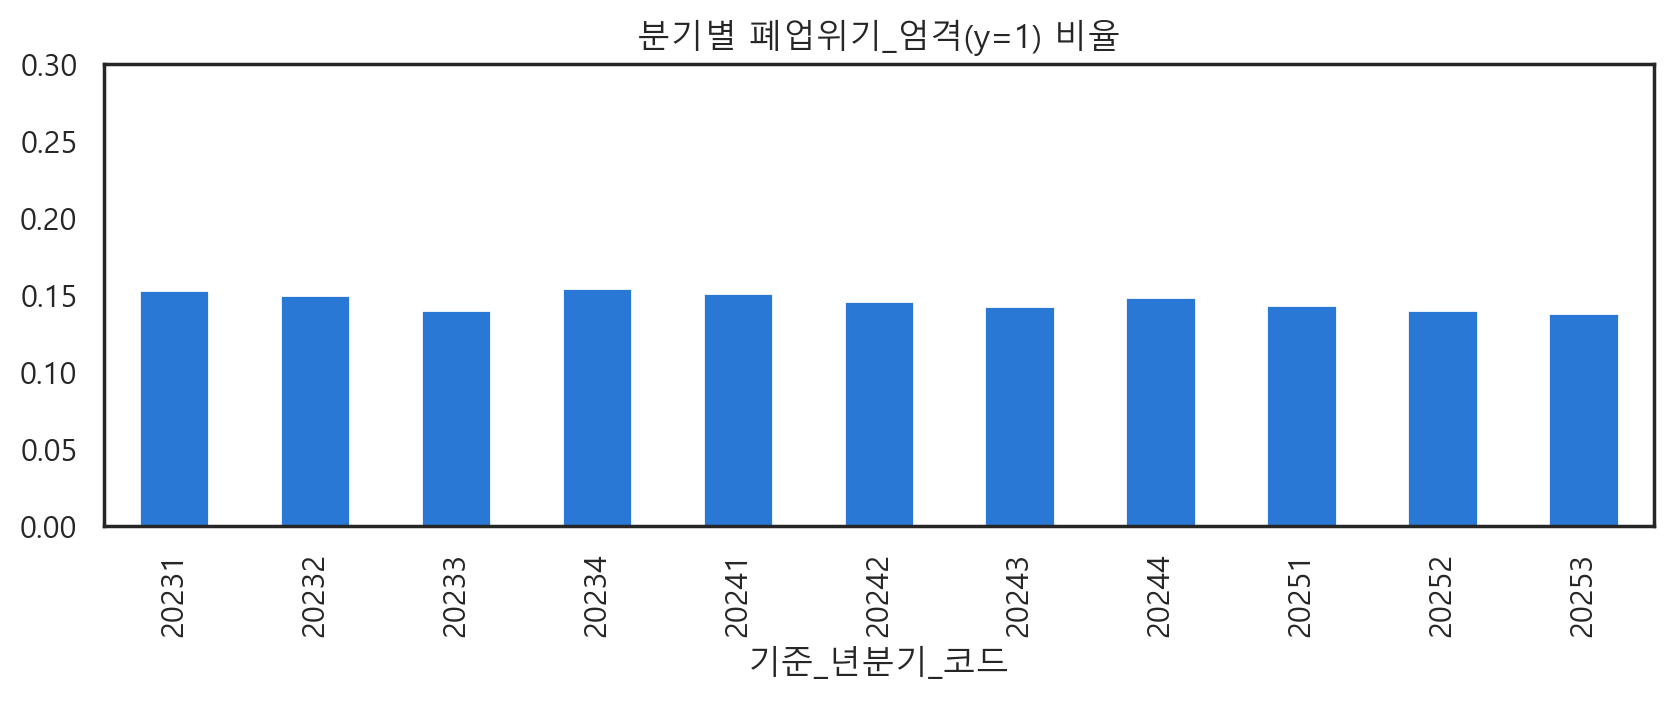

기준_년분기_코드
20231    0.153
20232    0.150
20233    0.140
20234    0.155
20241    0.151
20242    0.146
20243    0.143
20244    0.149
20251    0.144
20252    0.141
20253    0.138
Name: 폐업위기_엄격, dtype: float64

In [31]:
# 분기별 폐업위기 비율 (y가 있는 행)
rate = df.groupby('기준_년분기_코드')['폐업위기_엄격'].mean().dropna()
rate.plot.bar(color='#2a78d6', figsize=(10,3))
plt.title('분기별 폐업위기_엄격(y=1) 비율')
plt.ylim(0, 0.3)
plt.show()
rate.round(3)

In [32]:
# 행 수 확인 : 원본과 같아야 함
print('행 수 :', df.shape, '/ 키 중복 :', df.duplicated(['기준_년분기_코드','상권_코드','서비스_업종_코드']).sum())
print('학습 가능(y 있음) :', df['폐업위기'].notna().sum(), '/ 예측용(y 없음) :', df['폐업위기'].isna().sum())

## 여기서 y값없는 데이터느 25년도4분기 데이터로 26년도1분기 데이터가 없기에 학습용으로 사용불가함

행 수 : (261157, 137) / 키 중복 : 0
학습 가능(y 있음) : 233417 / 예측용(y 없음) : 27740


In [37]:
df = df.rename(columns={'폐업위기': '폐업위기_y1','폐업위기_엄격':'폐업위기_엄격_y2'})

In [39]:
df.to_csv(DATA_DIR + 'dataset.csv', index=False, encoding='utf-8-sig')

label_cols = ['다음분기_폐업_점포_수','다음분기_전체_점포_수','다음분기_폐업률','업종평균_폐업률',
              '폐업위기_y1','폐업위기_엄격_y2']
pd.Series(label_cols, name='X에서_제외할_컬럼').to_csv(DATA_DIR + 'label_cols.csv', index=False, encoding='utf-8-sig')
print('저장 완료 :', df.shape)

저장 완료 : (261157, 136)


In [55]:
df=pd.read_csv(DATA_DIR + 'dataset.csv')
label_cols = pd.read_csv(DATA_DIR +'label_cols.csv')['X에서_제외할_컬럼'].tolist()   # 저장할 때 쓴 컬럼명으로 맞추기
print(df.shape)
print(label_cols)

(261157, 136)
['다음분기_폐업_점포_수', '다음분기_전체_점포_수', '다음분기_폐업률', '업종평균_폐업률', '폐업위기_y1', '폐업위기_엄격_y2']


# ※종속변수 결측 행 처리
종속변수는 동일 상권·업종의 다음 분기 폐업 점포 수와 전체 점포 수로 산출
이 중 다음 분기 데이터가 존재하지 않는 종속변수를 산출할 수 없는 행
    1) 2025년 4분기 21,333행은 2026년 1분기 데이터 미반영으로 예측용 데이터로만 사용
    2) 2023년 1분기~2025년 3분기 중 다음 분기 없는 데이터 6,407행(전체의 2.5%)은 분석 제외
       이 행들은 전체 점포 수 중앙값이 4개로 나머지 데이터(7개)보다 작고, 49.2%가 점포 3개 이하
       -> 다음 분기 점포 감소로 서울시 추정매출 공개 기준(점포 3개 이상)에 미달하여 누락 추정
         (실제 폐업 발생 여부를 확인 어려움)

In [61]:
## 다음 분기 데이터가 없는 행 확인 (2025년 4분기 제외)
drop_cond = (df['다음분기_폐업_점포_수'].isna()) & (df['기준_년분기_코드'] != 20254)

print('삭제 전 :', df.shape)
df = df[~drop_cond].reset_index(drop=True)
print('삭제 후 :', df.shape)
print('2025년 4분기(예측용) 행 :', (df['기준_년분기_코드'] == 20254).sum())

삭제 전 : (261157, 136)
삭제 후 : (254750, 136)
2025년 4분기(예측용) 행 : 21333


In [63]:
df.to_csv('00_data/dataset.csv', index=False, encoding='utf-8-sig')

# 8. 상관분석

## 8.1 상관분석용 데이터 : 학습 기간(2023~2024)만 사용
- 05 모델링에서 **2024년 4분기까지 = 학습용**, 2025년 = 검증·테스트용으로 나눌 예정
- 상관분석 결과로 변수를 고르는 것도 '학습'의 일부 → 테스트 기간 정보가 섞이면 성능이 부풀려짐(데이터 누수)
- y가 없는 행(다음 분기가 없는 2025년 4분기 등)도 제외

In [64]:
df_corr = df[(df['기준_년분기_코드'] <= 20244) & (df['폐업위기_y1'].notna())]
print(df_corr.shape)
df_corr['기준_년분기_코드'].value_counts().sort_index()

(170738, 136)


20231    21504
20232    21541
20233    21486
20234    21397
20241    21347
20242    21295
20243    21143
20244    21025
Name: 기준_년분기_코드, dtype: int64

In [65]:
# 분석할 원본 수치형 변수 고르기
# 키·코드 : 숫자지만 의미 없는 번호 → 제외
# 라벨 컬럼 : 다음 분기 정보(=정답) → 제외
key_cols = ['기준_년분기_코드', '상권_코드', '서비스_업종_코드', '자치구_코드', '행정동_코드',
            '상권_변화_지표', '위도', '경도']
label_cols = ['다음분기_폐업_점포_수', '다음분기_전체_점포_수', '다음분기_폐업률',
              '업종평균_폐업률', '폐업위기_y1', '폐업위기_엄격_y2']

num_cols = df_corr.select_dtypes(include='number').columns.tolist()
x_cols = [c for c in num_cols if (c not in key_cols) and (c not in label_cols)]
print('분석 변수 수 :', len(x_cols))

분석 변수 수 : 116


# 3절. y와의 상관분석
## 3.1 스피어만 상관 (순위 기반 → 치우친 분포에도 안정적)

In [66]:
corr_y = df_corr[x_cols + ['폐업위기_y1', '폐업위기_엄격_y2']].corr(method='spearman')
corr_y = corr_y.loc[x_cols, ['폐업위기_y1', '폐업위기_엄격_y2']]
corr_y['절댓값_y1'] = corr_y['폐업위기_y1'].abs()
corr_y = corr_y.sort_values('절댓값_y1', ascending=False)
corr_y.head(20).round(3)

KeyboardInterrupt: 

# ※ 파생변수 생성
## 1. 자주 쓰는 합계 컬럼을 변수로
- 코드정리

In [42]:
T = df['당월_매출_금액']       # 총매출
S = df['전체_점포_수']         # 전체 점포 수
F = df['총_유동인구_수']       # 총 유동인구
R = df['총_상주인구_수']       # 총 상주인구
feat = pd.DataFrame(index=df.index)   # 파생변수를 담을 새 표

In [50]:
# 매출 8개변수
feat['총매출_log']         = np.log1p(T)
feat['점포당매출_log']     = np.log1p(T / S)
feat['건당단가_log']       = np.log1p(T / df['당월_매출_건수'])
feat['주말매출_비중']      = df['주말_매출_금액'] / T
feat['저녁야간매출_비중']  = (df['시간대_17_21_매출_금액'] + df['시간대_21_24_매출_금액']) / T
feat['심야매출_비중']      = df['시간대_00_06_매출_금액'] / T
feat['2030매출_비중']      = (df['연령대_20_매출_금액'] + df['연령대_30_매출_금액']) / (df['남성_매출_금액'] + df['여성_매출_금액'])
feat['요일매출_편차']      = df[[f'{w}요일_매출_금액' for w in '월화수목금토일']].div(T, axis=0).std(axis=1)

# 점포 5개변수
feat['전체점포수_log']     = np.log1p(S)
feat['폐업률_당분기']      = df['폐업_률'].clip(upper=100)
feat['개업률_당분기']      = df['개업_율'].clip(upper=100)
feat['프랜차이즈_비율']    = df['프랜차이즈_점포_수'] / S
feat['순증가율']           = (df['개업_점포_수'] - df['폐업_점포_수']) / S
feat.describe().head(3)

,총매출_log,점포당매출_log,건당단가_log,주말매출_비중,저녁야간매출_비중,심야매출_비중,2030매출_비중,요일매출_편차,전체점포수_log,폐업률_당분기,개업률_당분기,프랜차이즈_비율,순증가율
count,261157.000000,261157.000000,261157.000000,261157.000000,261157.000000,261157.000000,261154.000000,261157.000000,261157.000000,261157.000000,261157.000000,261157.000000,261157.000000
mean,18.910530,16.810872,10.619737,0.237716,0.395504,0.035881,0.294607,0.086052,2.247298,2.764314,2.690631,0.130118,-0.000742
std,1.968838,1.672378,1.297526,0.152588,0.231109,0.092801,0.219095,0.073743,0.809898,7.176147,6.770374,0.216454,0.087016


0         1.0
1         5.0
2         1.0
3         4.0
4         8.0
         ... 
261152    1.0
261153    0.0
261154    1.0
261155    0.0
261156    NaN
Name: 다음분기_폐업_점포_수, Length: 261157, dtype: float64